In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv(r"C:\Users\Jones Mbela\Desktop\RENNY\AI AND ML\MPESA Liquidity\data\synthetic_mobile_money_data.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')



In [44]:
agent_id = 'Agent_Urban_High'
agent_df = df[df['agent_id'] == agent_id]

print(f"data loaded for {agent_id}. Total records : {len(agent_id)}")
agent_df.head

data loaded for Agent_Urban_High. Total records : 16


<bound method NDFrame.head of                     agent_id        cash_in       cash_out  day_of_week  day  \
date                                                                           
2022-01-01  Agent_Urban_High  663065.768640  385896.584967            5    1   
2022-01-02  Agent_Urban_High  813458.943257  367494.080598            6    2   
2022-01-03  Agent_Urban_High  563061.405987  328669.515421            0    3   
2022-01-04  Agent_Urban_High  198647.222540  369903.195434            1    4   
2022-01-05  Agent_Urban_High  207225.541872  388389.330324            2    5   
...                      ...            ...            ...          ...  ...   
2024-12-27  Agent_Urban_High  897398.176632  355134.125342            4   27   
2024-12-28  Agent_Urban_High  718928.151751  404340.459725            5   28   
2024-12-29  Agent_Urban_High  655769.144513  376516.614117            6   29   
2024-12-30  Agent_Urban_High  610669.642440  289494.697245            0   30   
2024-12-31

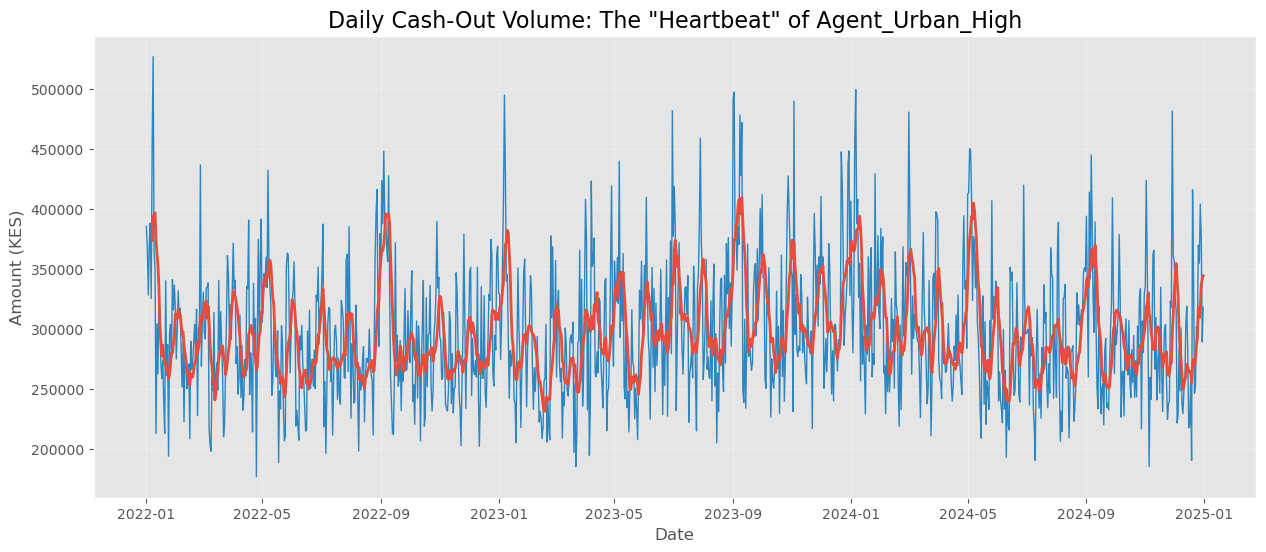

In [45]:
# Daily trends

agent_df = agent_df.sort_index()
plt.figure(figsize=(15, 6))
plt.plot(agent_df.index, agent_df['cash_out'], color='#2E86C1', linewidth=1)
plt.plot(agent_df.index,agent_df['cash_out'].rolling(window=7).mean(),color = '#E74C3C', linewidth=2, label='7-Day Trend')
plt.title(f'Daily Cash-Out Volume: The "Heartbeat" of {agent_id}', fontsize=16)
plt.ylabel('Amount (KES)')
plt.xlabel('Date')
plt.grid(True, alpha=0.3)
plt.show()


C:\Users\Jones Mbela\AppData\Local\Temp\ipykernel_35932\3887778979.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='period_type', y='cash_out', data=agent_df, palette='Blues_d')


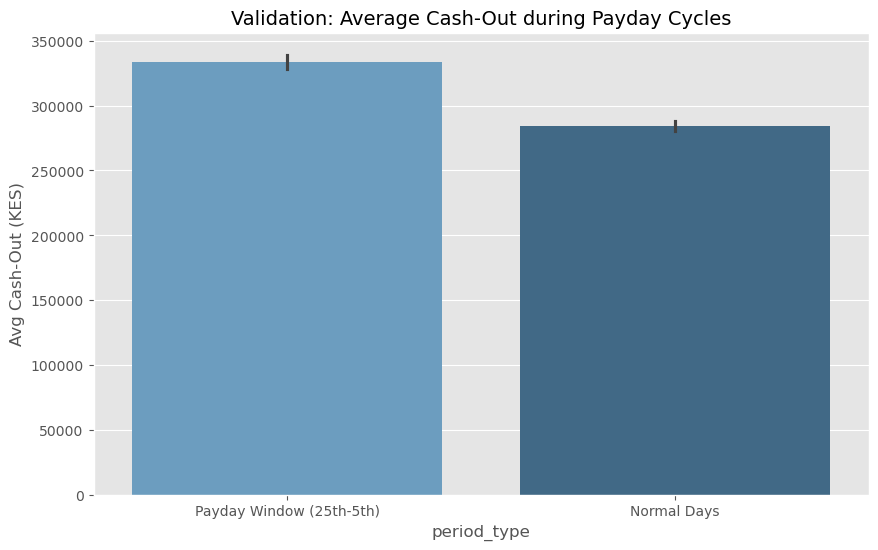

Analysis: Cash-out increases by 17.46% during the payday window.


In [46]:
# Payday effect: average cashout during payday window vs normal days
# Create a cleaner label for the plot
agent_df['period_type'] = agent_df['is_payday_window'].map({True: 'Payday Window (25th-5th)', False: 'Normal Days'})

plt.figure(figsize=(10, 6))
sns.barplot(x='period_type', y='cash_out', data=agent_df, palette='Blues_d')
plt.title('Validation: Average Cash-Out during Payday Cycles', fontsize=14)
plt.ylabel('Avg Cash-Out (KES)')
plt.show()

# Calculate the exact percentage increase for your resume!
payday_mean = agent_df[agent_df['is_payday_window'] == True]['cash_out'].mean()
normal_mean = agent_df[agent_df['is_payday_window'] == False]['cash_out'].mean()
increase = ((payday_mean - normal_mean) / normal_mean) * 100
print(f"Analysis: Cash-out increases by {increase:.2f}% during the payday window.")


C:\Users\Jones Mbela\AppData\Local\Temp\ipykernel_35932\2724916673.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='month_type', y='cash_out', data=agent_df, palette='YlOrRd')


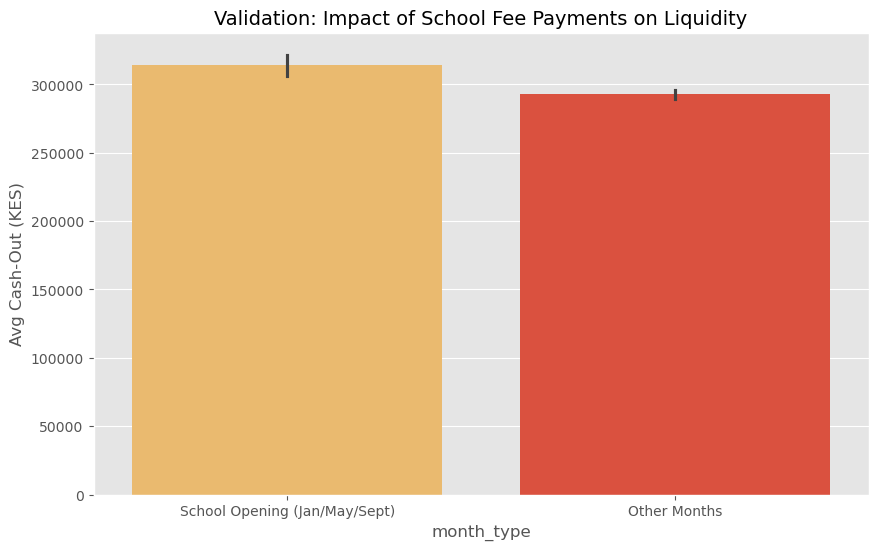

In [47]:
# School Fee effect 
# Mark the school months
agent_df['is_school_month'] = agent_df['month'].isin([1, 5, 9])
agent_df['month_type'] = agent_df['is_school_month'].map({True: 'School Opening (Jan/May/Sept)', False: 'Other Months'})

plt.figure(figsize=(10, 6))
sns.barplot(x='month_type', y='cash_out', data=agent_df, palette='YlOrRd')
plt.title('Validation: Impact of School Fee Payments on Liquidity', fontsize=14)
plt.ylabel('Avg Cash-Out (KES)')
plt.show()



In [48]:
# Feature engineering
# 1. Lag Features: What happened yesterday and 7 days ago?
agent_df['cash_out_lag1'] = agent_df['cash_out'].shift(1)
agent_df['cash_out_lag7'] = agent_df['cash_out'].shift(7)

# 2. Rolling Averages: What is the trend of the last week?
agent_df['rolling_mean_7d'] = agent_df['cash_out'].rolling(window=7).mean()

# 3. Weekend Flag: Is it a high-volume weekend?
agent_df['is_weekend'] = agent_df['day_of_week'].isin([4, 5, 6]).astype(int)

# Drop rows with NaN from lagging
agent_df.dropna(inplace=True)

print(" Feature Engineering Complete. New columns added:")
print(agent_df[['cash_out', 'cash_out_lag1', 'rolling_mean_7d', 'is_weekend']].head())


 Feature Engineering Complete. New columns added:
                 cash_out  cash_out_lag1  rolling_mean_7d  is_weekend
date                                                                 
2022-01-08  527065.667519  452681.336292    394266.159481           1
2022-01-09  364338.802142  527065.667519    393815.405416           1
2022-01-10  350521.539090  364338.802142    396937.123083           0
2022-01-11  213104.454084  350521.539090    374537.302891           0
2022-01-12  304525.080786  213104.454084    362556.695814           0


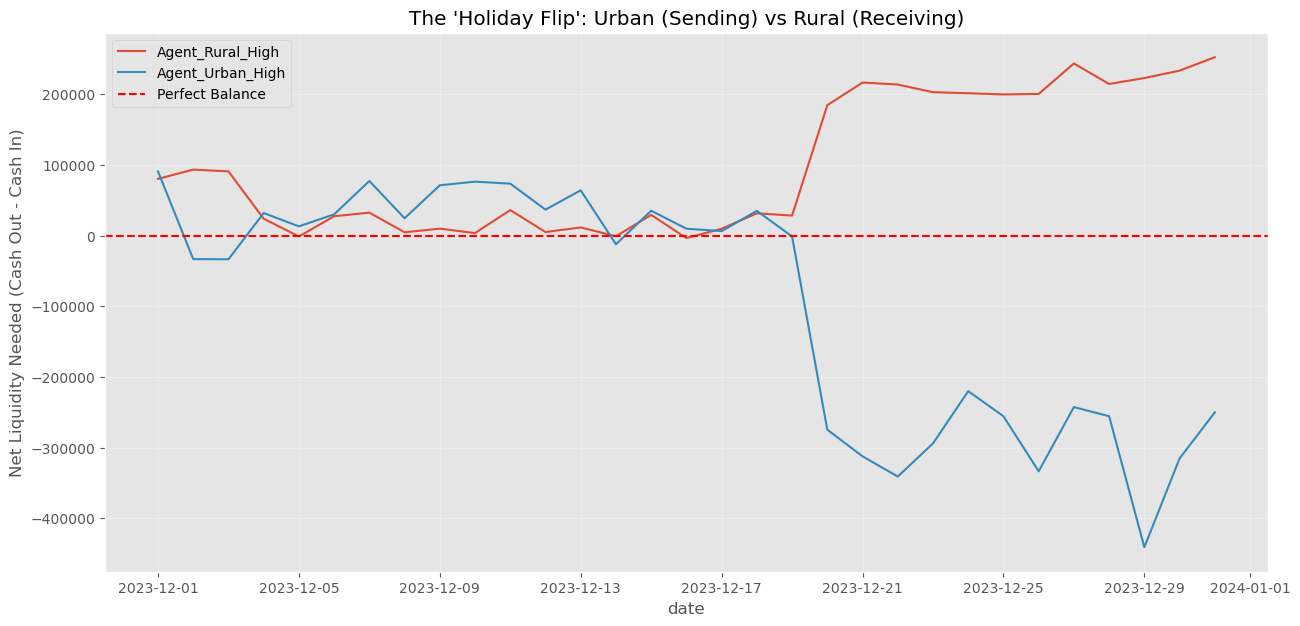

In [49]:
# Urban vs rural-proving that holidays affect Urban and Rural agents differently

df.index = pd.to_datetime(df.index)

# Sorting index
df= df.sort_index()

#filtering dec chrisi 2023
dec_data = df['2023-12-01':'2023-12-31']
#filter for 1 urban and 1 rural
comparison = dec_data[dec_data['agent_id'].isin(['Agent_Urban_High','Agent_Rural_High'])]

plt.figure(figsize=(15, 7))
sns.lineplot(data=comparison, x=comparison.index, y='net_liquidity_needed', hue='agent_id')

plt.axhline(0, color='red', linestyle='--', label='Perfect Balance')

plt.title("The 'Holiday Flip': Urban (Sending) vs Rural (Receiving)")
plt.ylabel("Net Liquidity Needed (Cash Out - Cash In)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


C:\Users\Jones Mbela\AppData\Local\Temp\ipykernel_35932\1675003145.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='day_name', y='cash_out',


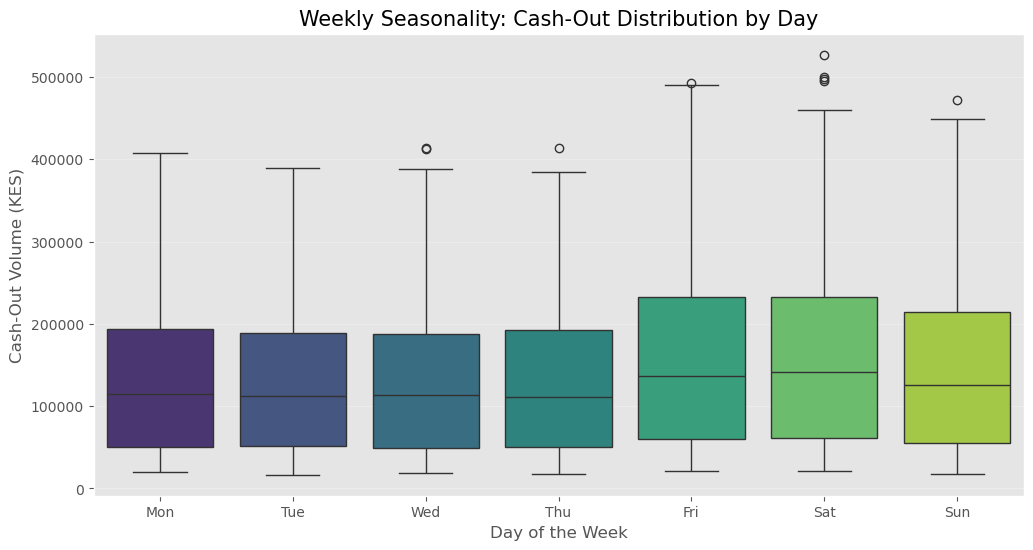

In [50]:
# Day of week seasonality (Box PLot) - Identify days of week requiring  the most "float" or "Cash"


#Dict fomapping numbers to days of week
day_map = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
df['day_name'] = df['day_of_week'].map(day_map)


# 2. Plotting the Box Plot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='day_name', y='cash_out', 
            order=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'],
            palette='viridis')

# 3. Customizing the plot
plt.title("Weekly Seasonality: Cash-Out Distribution by Day", fontsize=15)
plt.ylabel("Cash-Out Volume (KES)")
plt.xlabel("Day of the Week")
plt.grid(axis='y', alpha=0.3)

plt.show()

<Axes: xlabel='day_name', ylabel='cash_out'>

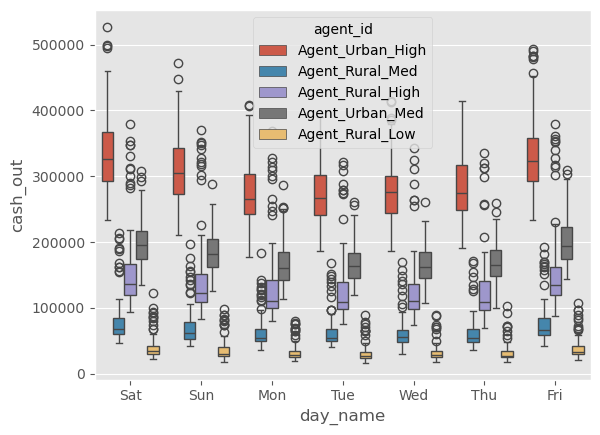

In [51]:
#Urban vs rural weekend
sns.boxplot(data=df, x='day_name', y='cash_out', hue='agent_id')

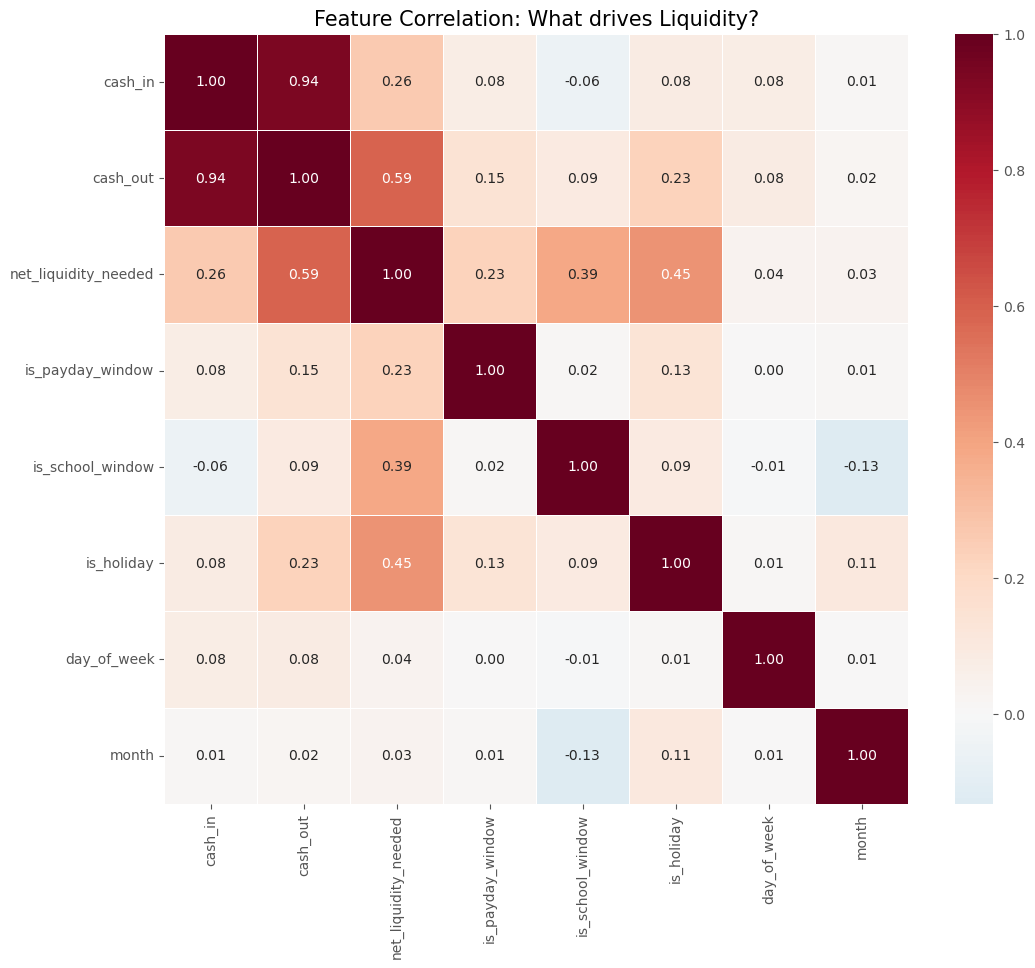

In [39]:
# Correlation Heat Map- Seeing which external variables have the strongest stats relationship

# Selecting numeric and boolean columns for correlation

corr_cols = [
    'cash_in', 'cash_out', 'net_liquidity_needed', 
    'is_payday_window', 'is_school_window', 'is_holiday', 
    'day_of_week', 'month'
]

corr_matrix = df[corr_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f', linewidths=0.5)

plt.title("Feature Correlation: What drives Liquidity?", fontsize=15)
plt.show()

In [40]:
# Cumulative Liq drain

C:\Users\Jones Mbela\AppData\Local\Temp\ipykernel_35932\2693882210.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rural_q4['rolling_drain'] = rural_q4['net_liquidity_needed'].rolling(window=7).sum()


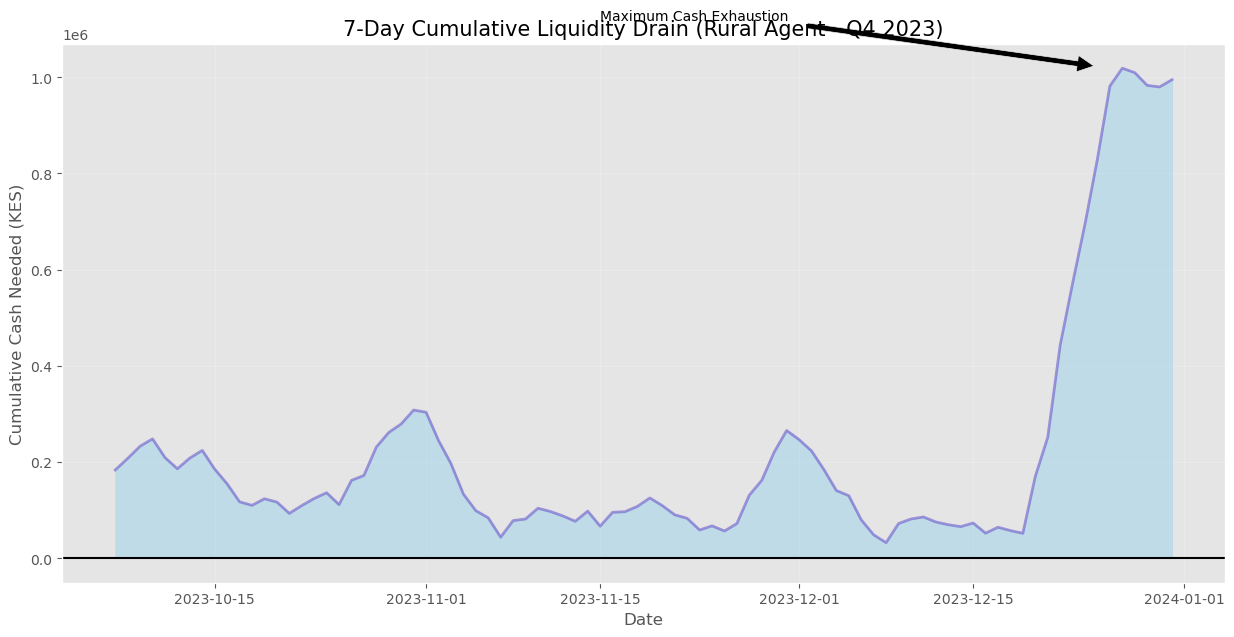

In [41]:
# Cumulative Liquidity Drain - area chart

# A 7-day rolling sum tells us: "If I didn't go to the bank for the last 7 days, how much total cash (or float) would I have gained or lost?"
# Focusing on rural
rural_agent = df[df['agent_id'] == 'Agent_Rural_High'].copy()
rural_q4 = rural_agent.loc['2023-10-01':'2023-12-31']

#Rolling sum
rural_q4['rolling_drain'] = rural_q4['net_liquidity_needed'].rolling(window=7).sum()

plt.figure(figsize=(15, 7))
plt.fill_between(rural_q4.index, rural_q4['rolling_drain'], color="skyblue", alpha=0.4)
plt.plot(rural_q4.index, rural_q4['rolling_drain'], color="Slateblue", alpha=0.6, linewidth=2)

plt.axhline(0, color='black', linestyle='-')
plt.title("7-Day Cumulative Liquidity Drain (Rural Agent - Q4 2023)", fontsize=15)
plt.ylabel("Cumulative Cash Needed (KES)")
plt.xlabel("Date")
plt.grid(True, alpha=0.2)

#Highlight chrisi peak
plt.annotate('Maximum Cash Exhaustion', 
             xy=(pd.to_datetime('2023-12-26'), rural_q4['rolling_drain'].max()),
             xytext=(pd.to_datetime('2023-11-15'), rural_q4['rolling_drain'].max() + 100000),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()